In [2]:
import ibis
from ibis import _, selectors as s
from utils.f_0_dirs import get_data_dirs
dirs = get_data_dirs("descriptives")
con = ibis.duckdb.connect(dirs.db_path, read_only=True)

# 2. Spatial distance $d_1$

Number of firms with more than 5,000 peers: 30,557


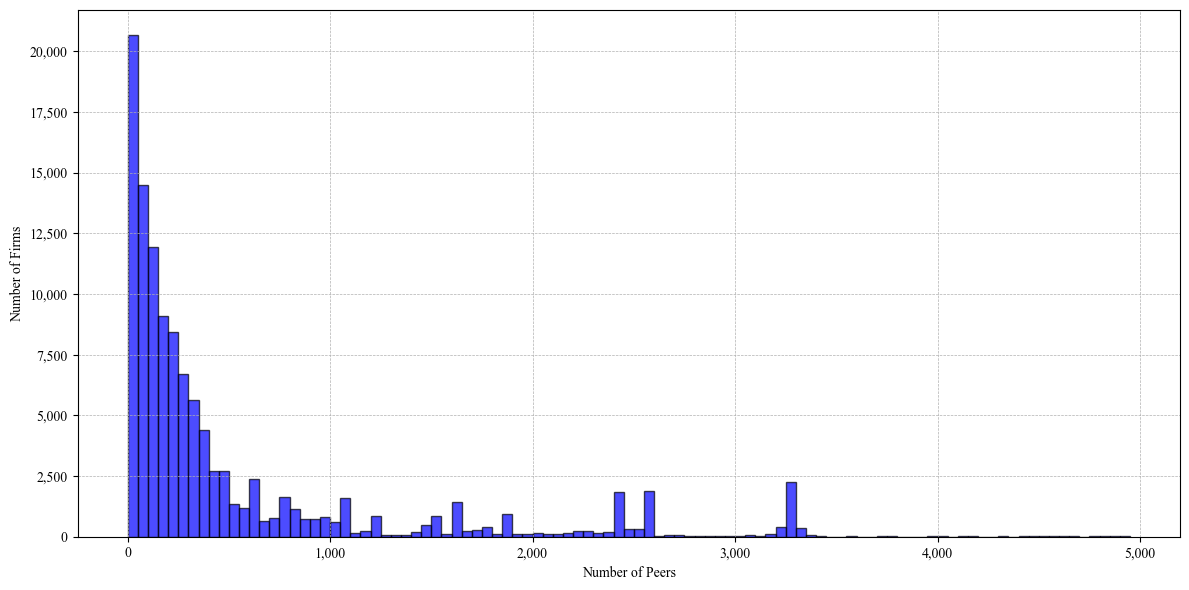

Plotting sample of distance: 1% sample (7,345,257)


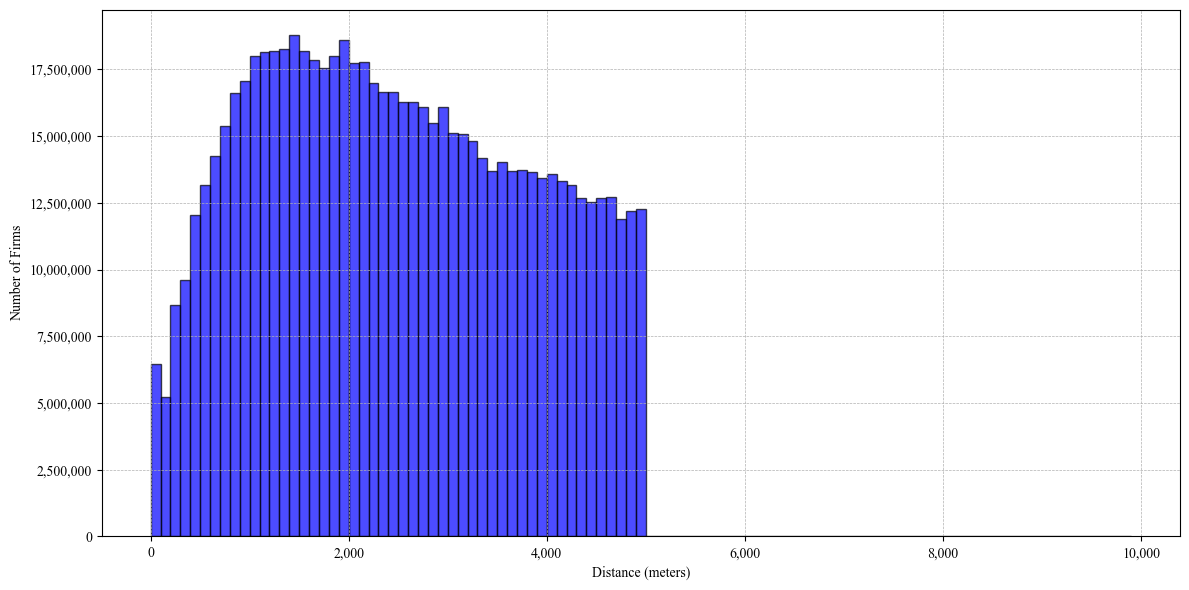

              name  pos     type    count  nulls   unique         mean  \
0  distance_meters    0  float64  7343226      0  2000484  2476.255935   

           std  min          p25          p50          p75          max  
0  1336.642709  0.0  1358.816203  2386.824861  3583.598572  4999.999564  


AttributeError: 'DataFrame' object has no attribute 'append'

In [3]:
# Number of peers per firm
# Group by firm_i and count the number of peers (firm_j) for each firm_i
# Group by firm_j and count the number of peers (firm_i) for each firm_j
# Sum then together for each firm to get total number of peers
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

t_distances = con.table("working_distance_ttwa_km")
sample_size = 0.01

t_peer_counts_i = (
    t_distances
    .select("firm_i")
    .group_by("firm_i")
    .aggregate(num_peers_i=_.count())
)
df_peer_counts_i = t_peer_counts_i.execute()
df_distances = (
    t_distances
    .select('distance_meters')
    .sample(0.01)
    .execute()
)
# Above threshold
threshold = 5000
above_t = (
    t_peer_counts_i
    .filter(_.num_peers_i > threshold)
    .count()
    .execute()
)
print(f"Number of firms with more than {threshold:,} peers: {above_t:,}")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman']

plt.figure(figsize=(12, 6))
plt.hist(
    df_peer_counts_i['num_peers_i'],
    bins=range(0, threshold, 50),
    alpha=0.7,
    color='blue',
    edgecolor='black'
)
plt.xlabel("Number of Peers")
plt.ylabel("Number of Firms")
plt.grid(True, which="both", ls="--", linewidth=0.5)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

n_dist = df_distances.shape[0]
print(f"Plotting sample of distance: 1% sample ({n_dist:,})")
plt.figure(figsize=(12, 6))
weights = [np.full_like(d, 1/sample_size) for d in range(0, n_dist)]
plt.hist(
    df_distances['distance_meters'],
    weights=weights,
    bins=range(0, 10000, 100),
    alpha=0.7,
    color='blue',
    edgecolor='black'
)
plt.xlabel("Distance (meters)")
plt.ylabel("Number of Firms")
plt.grid(True, which="both", ls="--", linewidth=0.5)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

# Summary statistics
df_counts_summ = (
    t_peer_counts_i
    .select('num_peers_i')
    .aggregate(
        count=_.count(),
        mean=_['num_peers_i'].mean(),
        median=_['num_peers_i'].median(),
        std=_['num_peers_i'].std(),
        min=_['num_peers_i'].min(),
        max=_['num_peers_i'].max()
    )
    .execute()
)
print(
    t_distances
    .select('distance_meters')
    .sample(0.01)
    .describe()
    .execute()
)
df_distances_summ = (
    t_distances
    .select('distance_meters')
    .sample(0.01)
    .aggregate(
        count=_.count(),
        mean=_['distance_meters'].mean(),
        median=_['distance_meters'].median(),
        std=_['distance_meters'].std(),
        min=_['distance_meters'].min(),
        max=_['distance_meters'].max()
    )
    .execute()
)
# Join these two tables. They each have 1 row and 6 columns
# So have them be 2 rows with the same columns
# And add an index/first column label describing each
df_combined = (
    df_counts_summ
    .assign(stat_type='num_peers_i')
    .append(df_distances_summ.assign(stat_type='distance_km'))
    .set_index('stat_type')
)
display(df_combined)

In [7]:
# Join these two tables. They each have 1 row and 6 columns
# So have them be 2 rows with the same columns
# And add an index/first column label describing each
import pandas as pd

df_combined = (
    pd.concat(
        [df_counts_summ.assign(stat_type='num_peers_i'),
        df_distances_summ.assign(stat_type='distance_km')]
    )
    .set_index('stat_type')
)
display(df_combined)

,count,mean,median,std,min,max
stat_type,,,,,,
num_peers_i,147419,4981.358943,324.000000,9187.567217,1.0,87476.000000
distance_km,7345880,2476.202031,2386.456781,1336.717611,0.0,4999.999796


# Distances histogram

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import ibis
from ibis import _
from utils.f_0_dirs import get_data_dirs

cut_off = 6000
sample_fraction = 0.001  # 0.1% sample for plotting
table_out_name = "working_distance_ttwa_km"
fixed_name = "working_fixed"

dirs = get_data_dirs(segment="calculations")
con = ibis.duckdb.connect(dirs.db_path)
t_distances = con.table(table_out_name)
t_fixed = con.table(fixed_name).select("registered_number", "pc8", "lat_lon5", "address_lvl", "address_case")
tf_i = t_fixed.alias("tf_i").rename({f"{col}_i": col for col in t_fixed.columns})
tf_j = t_fixed.alias("tf_j").rename({f"{col}_j": col for col in t_fixed.columns})

df_distances = (
    t_distances
    .sample(0.001)
    .left_join(tf_i, t_distances.firm_i == tf_i.registered_number_i)
    .left_join(tf_j, t_distances.firm_j == tf_j.registered_number_j)
    .select(["distance_meters", "address_lvl_i", "address_case_i", "address_lvl_j", "address_case_j"])
    .mutate(
        # Note: Casting the boolean to an integer ensures the multiplication works safely across SQL backends
        address_score_i = _.address_lvl_i + (_.address_case_i == 'ro').cast('int8') * 2,
        address_score_j = _.address_lvl_j + (_.address_case_j == 'ro').cast('int8') * 2,
    )
    .mutate(
        address_score_total = _.address_score_i + _.address_score_j
    )
    .filter(_.address_score_total.notnull())
    .execute()
)
# 1. Group by score and collect distances into a list natively in DuckDB
df_grouped = (
    ibis.memtable(df_distances)
    .group_by("address_score_total")
    .aggregate(distances=_.distance_meters.collect())
    .order_by("address_score_total")
    .execute()
)

# 2. Extract unique scores and numpy arrays for matplotlib
unique_scores = df_grouped["address_score_total"].tolist()
data_to_plot = [np.asarray(d) for d in df_grouped["distances"]]

# 2. Group the distances by their total score into a list of arrays
# Matplotlib requires the shape: [array(score_1_distances), array(score_2_distances), ...]
unique_scores = sorted(df_distances['address_score_total'].unique())
data_to_plot = [
    df_distances[df_distances['address_score_total'] == score]['distance_meters'].values 
    for score in unique_scores
]

# Create labels mapping to each array for the legend
labels = [f"Score: {int(score)}" for score in unique_scores]

color_map = [
    'lightblue', 'lightgreen', 'lightcoral', 'lightgoldenrodyellow', 'lightpink', 'lightgray',
    'purple', 'orange', 'cyan', 'magenta', 'yellow', 'brown', 'teal', 'navy', 'olive'
]

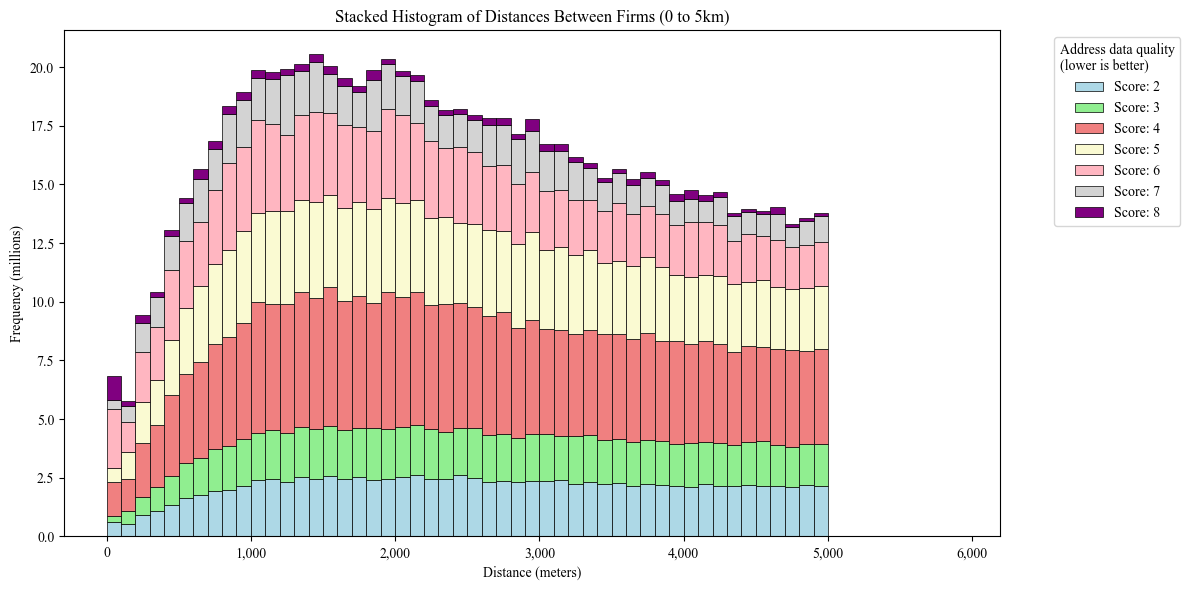

In [5]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman']
weights = [np.full_like(d, 1/sample_fraction / 1000000) for d in data_to_plot]
plt.figure(figsize=(12, 6))
plt.hist(
    data_to_plot,
    weights=weights,  # Scale to millions
    bins=np.arange(0, cut_off, 100),
    stacked=True, 
    color=color_map[:len(unique_scores)], 
    label=labels,
    edgecolor='black',
    linewidth=0.5
)
plt.title(f'Stacked Histogram of Distances Between Firms (0 to 5km)')
plt.xlabel('Distance (meters)')
plt.ylabel('Frequency (millions)')
ax = plt.gca()  # Get current axis
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.1f}'))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend(title='Address data quality\n(lower is better)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ensures the external legend isn't cut off
plt.show()